# Assignment 5:

##Task 1: k-Fold Cross-Validation

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

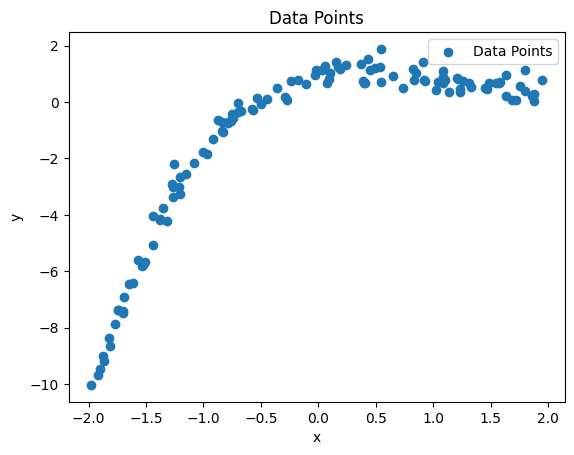

In [ ]:
# 1. Data Generation
np.random.seed(42) # For reproducibility
n = 120
x = np.random.uniform(-2, 2, n)
epsilon = np.random.normal(0, 0.3, n)

# True relationship
y = 1 + 0.8*x - 1.5*(x**2) + 0.5*(x**3) + epsilon
plt.scatter(x, y, label='Data Points')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Data Points')
plt.legend()
plt.show()

In [ ]:
# 2. Train-Test Split (from scratch)

# Shuffle indices to ensure random distribution
indices = np.arange(n)
np.random.shuffle(indices)

x_shuffled = x[indices]
y_shuffled = y[indices]

# Keep 20% for independent testing (24 samples)
test_size = int(0.2 * n)
x_test, y_test = x_shuffled[:test_size], y_shuffled[:test_size]
x_cv, y_cv = x_shuffled[test_size:], y_shuffled[test_size:]

In [ ]:
# 3. K-Fold Splitting Logic (from scratch)
def get_kfold_indices(data_length, k):
    """Yields k pairs of (train_indices, val_indices)"""
    fold_size = data_length // k
    folds = []
    indices = np.arange(data_length)

    for i in range(k):
        val_start = i * fold_size
        # Handle remainder for the last fold if data_length isn't perfectly divisible
        val_end = val_start + fold_size if i < k - 1 else data_length

        val_idx = indices[val_start:val_end]
        train_idx = np.concatenate([indices[:val_start], indices[val_end:]])

        folds.append((train_idx, val_idx))
    return folds

def get_poly_features(x_data, degree):
    # np.vander generates [x^n, x^(n-1), ..., x^0]. We reverse it for standard [1, x, x^2, ...]
    return np.vander(x_data, degree + 1, increasing=True)

In [ ]:
# 4. Run Cross-Validation
degrees = [1, 2, 3, 5, 9]
k_values = [5, 10]
cv_results = {5: [], 10: []}

for k in k_values:
    folds = get_kfold_indices(len(x_cv), k)

    for p in degrees:
        X_poly = get_poly_features(x_cv, p)
        fold_mses = []

        for train_idx, val_idx in folds:
            X_train, Y_train = X_poly[train_idx], y_cv[train_idx]
            X_val, Y_val = X_poly[val_idx], y_cv[val_idx]

            # Fit model without intercept since X_poly includes x^0 (column of 1s)
            model = LinearRegression(fit_intercept=False)
            model.fit(X_train, Y_train)

            preds = model.predict(X_val)
            mse = mean_squared_error(Y_val, preds)
            fold_mses.append(mse)

        mean_cv_mse = np.mean(fold_mses)
        cv_results[k].append(mean_cv_mse)

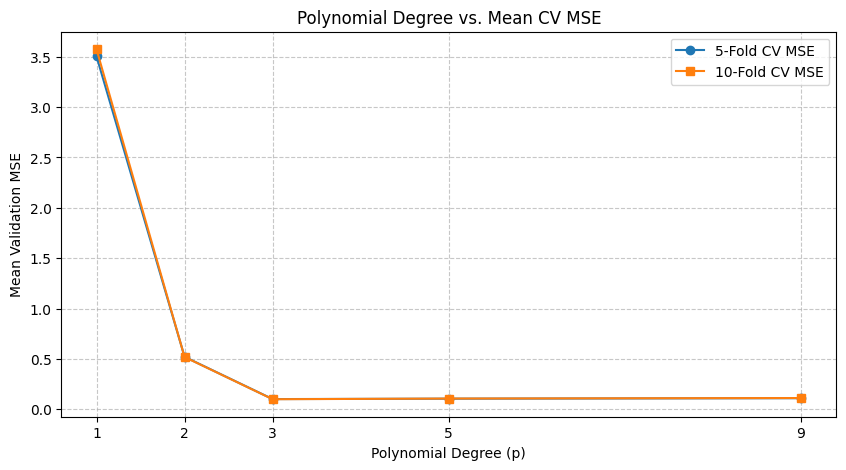

In [ ]:
# 5. Plotting CV Results
plt.figure(figsize=(10, 5))
plt.plot(degrees, cv_results[5], marker='o', label='5-Fold CV MSE')
plt.plot(degrees, cv_results[10], marker='s', label='10-Fold CV MSE')
plt.xlabel('Polynomial Degree (p)')
plt.ylabel('Mean Validation MSE')
plt.title('Polynomial Degree vs. Mean CV MSE')
plt.xticks(degrees)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
print(f"5-Fold CV MSE: {cv_results[5]}")
print(f"10-Fold CV MSE: {cv_results[10]}")

print(f"Best 5-Fold CV MSE: {min(cv_results[5])}")
print(f"Best 10-Fold CV MSE: {min(cv_results[10])}")

5-Fold CV MSE: [np.float64(3.503805694643068), np.float64(0.5203392547308876), np.float64(0.10079463350327089), np.float64(0.10485908198715632), np.float64(0.10956192771681424)]
10-Fold CV MSE: [np.float64(3.5744043115812785), np.float64(0.5185095901764664), np.float64(0.09942839727770011), np.float64(0.10600958150483494), np.float64(0.11116055537401048)]
Best 5-Fold CV MSE: 0.10079463350327089
Best 10-Fold CV MSE: 0.09942839727770011


In [ ]:
# 6. Final Evaluation on Independent Test Set
# Based on the plot, identify the degree with the lowest CV MSE (e.g., using 10-fold results)
best_degree_idx = np.argmin(cv_results[10])
best_degree = degrees[best_degree_idx]
print(f"Selected Best Polynomial Degree: {best_degree}")

# Fit model using ALL non-test data
X_cv_poly_best = get_poly_features(x_cv, best_degree)
X_test_poly_best = get_poly_features(x_test, best_degree)

final_model = LinearRegression(fit_intercept=False)
final_model.fit(X_cv_poly_best, y_cv)

# Calculate final Train and Test MSE
train_preds = final_model.predict(X_cv_poly_best)
test_preds = final_model.predict(X_test_poly_best)

final_train_mse = mean_squared_error(y_cv, train_preds)
final_test_mse = mean_squared_error(y_test, test_preds)

print(f"Final Train MSE: {final_train_mse:.4f}")
print(f"Final Test MSE:  {final_test_mse:.4f}")

Selected Best Polynomial Degree: 3
Final Train MSE: 0.0935
Final Test MSE:  0.0576


### Model Capacity
* **Underfitting:** Models with polynomial degrees 1 and 2 exhibit severe underfitting, producing the highest Mean Squared Errors (MSE of ~3.50 and ~0.52 respectively). They lack the necessary capacity to map the non-linear structure of the underlying data.
* **Optimal Capacity:** Degree 3 represents optimal model capacity, achieving the lowest validation errors for both 5-fold (~0.101) and 10-fold (~0.099) configurations. This aligns perfectly with the true underlying cubic function of the generated data.
* **Overfitting:** As capacity increases to degrees 5 and 9, the validation MSE begins to incrementally rise (reaching ~0.111 for 10-fold at degree 9). This indicates overfitting, where excess model capacity begins memorizing the random Gaussian noise ($\epsilon$) in the training folds, slightly degrading its ability to generalize.
* **Final Verification:** Retraining the chosen degree 3 model on all cross-validation data yields a final Train MSE of 0.0935 and an independent Test MSE of 0.0576. These values are very close to the true noise variance of the generated data ($0.3^2 = 0.09$), confirming that the chosen capacity cleanly captured the signal while ignoring the noise.

### 5-Fold vs. 10-Fold Cross-Validation
* **Bias and Error Estimates:** 10-fold cross-validation produces a slightly lower optimal MSE (0.0994) than 5-fold cross-validation (0.1008). Because 10-fold CV uses a larger proportion of the available data for training in each split (90% vs. 80%), the resulting models are closer to the final model trained on all data, reducing the pessimistic bias in the error estimate.
* **Trend Consistency:** Despite minor numerical differences, both 5-fold and 10-fold CV curves are nearly identical in shape and successfully select degree 3 as the definitive best model.
* **Computational Cost vs. Precision:** 10-fold requires training 50 models (10 folds × 5 degrees), whereas 5-fold requires only 25. For this dataset, the extra computation of 10-fold provided only a marginal refinement in the MSE estimate, meaning 5-fold was equally effective for hyperparameter selection at half the computational cost.

#Task 2: Regression with k-Fold Cross-Validation on a Real Dataset

In [ ]:
import numpy as np

from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


# --------------------------------------------------
# 1. Load the Diabetes dataset
# --------------------------------------------------

diabetes = load_diabetes()

X = diabetes.data
y = diabetes.target

print("X shape:", X.shape)
print("y shape:", y.shape)


# --------------------------------------------------
# 2. Set number of folds
# --------------------------------------------------

k = 5


# --------------------------------------------------
# 3. Create shuffled indices
# --------------------------------------------------

n = len(X)

indices = np.arange(n)

np.random.seed(42)
np.random.shuffle(indices)


# --------------------------------------------------
# 4. Split indices into k folds
# --------------------------------------------------

folds = np.array_split(indices, k)


# Store MSE of every fold
mse_values = []


# --------------------------------------------------
# 5. Perform k-fold cross-validation
# --------------------------------------------------

for i in range(k):

    print("\nFold", i + 1)

    # Validation indices
    validation_indices = folds[i]

    # Training indices = all other folds
    training_indices = np.concatenate(
        [folds[j] for j in range(k) if j != i]
    )

    # Create training and validation datasets
    X_train = X[training_indices]
    y_train = y[training_indices]

    X_val = X[validation_indices]
    y_val = y[validation_indices]


    # --------------------------------------------------
    # 6. Calculate mean and standard deviation
    #    using TRAINING data only
    # --------------------------------------------------

    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0)


    # --------------------------------------------------
    # 7. Standardize training and validation data
    # --------------------------------------------------

    X_train_scaled = (X_train - mean) / std

    X_val_scaled = (X_val - mean) / std


    # --------------------------------------------------
    # 8. Train Linear Regression
    # --------------------------------------------------

    model = LinearRegression()

    model.fit(X_train_scaled, y_train)


    # --------------------------------------------------
    # 9. Predict validation data
    # --------------------------------------------------

    y_pred = model.predict(X_val_scaled)


    # --------------------------------------------------
    # 10. Calculate MSE
    # --------------------------------------------------

    mse = mean_squared_error(y_val, y_pred)

    mse_values.append(mse)

    print("Validation MSE:", mse)


# --------------------------------------------------
# 11. Calculate mean CV MSE
# --------------------------------------------------

mean_cv_mse = np.mean(mse_values)


# --------------------------------------------------
# 12. Calculate standard deviation
# --------------------------------------------------

std_cv_mse = np.std(mse_values)


print("\n--------------------------------")
print("5-Fold Cross-Validation Results")
print("--------------------------------")

print("MSE values:", mse_values)
print("Mean CV MSE:", mean_cv_mse)
print("Standard deviation:", std_cv_mse)

X shape: (442, 10)
y shape: (442,)

Fold 1
Validation MSE: 2900.1936284934823

Fold 2
Validation MSE: 2662.6376086196155

Fold 3
Validation MSE: 3312.3058888352602

Fold 4
Validation MSE: 2797.8835525557442

Fold 5
Validation MSE: 3403.8877929322557

--------------------------------
5-Fold Cross-Validation Results
--------------------------------
MSE values: [2900.1936284934823, 2662.6376086196155, 3312.3058888352602, 2797.8835525557442, 3403.8877929322557]
Mean CV MSE: 3015.381694287272
Standard deviation: 291.23979402678145


In [ ]:
# 10-Fold Cross-Validation

k = 10

# Shuffle the indices
indices = np.arange(len(X))
np.random.seed(42)
np.random.shuffle(indices)

# Divide data into 10 folds
folds = np.array_split(indices, k)

mse_scores_10 = []

for i in range(k):

    # Validation data = current fold
    val_indices = folds[i]

    # Training data = all other folds
    train_indices = np.concatenate(
        [folds[j] for j in range(k) if j != i]
    )

    # Split X and y
    X_train = X[train_indices]
    X_val = X[val_indices]

    y_train = y[train_indices]
    y_val = y[val_indices]

    # Standardization using ONLY training data
    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0)

    # Avoid division by zero
    std[std == 0] = 1

    X_train_scaled = (X_train - mean) / std
    X_val_scaled = (X_val - mean) / std

    # Train Linear Regression
    model = LinearRegression()
    model.fit(X_train_scaled, y_train)

    # Predict validation data
    y_pred = model.predict(X_val_scaled)

    # Calculate MSE
    mse = mean_squared_error(y_val, y_pred)

    mse_scores_10.append(mse)

    print(f"Fold {i+1}: MSE = {mse:.4f}")



print("\n--------------------------------")
print("10-Fold Cross-Validation Results")
print("--------------------------------")

mean_cv_mse_10 = np.mean(mse_scores_10)
std_cv_mse_10 = np.std(mse_scores_10)

print("MSE values:", mse_scores_10)
print("Mean CV MSE:", mean_cv_mse_10)
print("Standard deviation:", std_cv_mse_10)

Fold 1: MSE = 2743.9112
Fold 2: MSE = 2979.1913
Fold 3: MSE = 2427.0738
Fold 4: MSE = 2943.5347
Fold 5: MSE = 3649.9546
Fold 6: MSE = 2941.1785
Fold 7: MSE = 2408.5224
Fold 8: MSE = 3170.7366
Fold 9: MSE = 3485.6804
Fold 10: MSE = 3486.7848

--------------------------------
10-Fold Cross-Validation Results
--------------------------------
MSE values: [2743.9112377576985, 2979.191280644757, 2427.073754185976, 2943.5347274155192, 3649.9546285647843, 2941.1784906062785, 2408.5223553976607, 3170.7366490780564, 3485.680361433649, 3486.784797708416]
Mean CV MSE: 3023.6568282792796
Standard deviation: 408.60659088926326


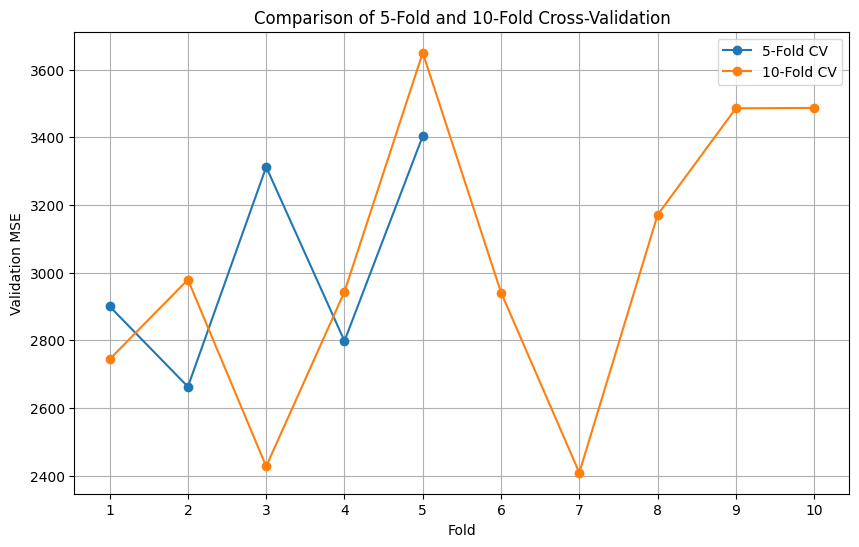

In [ ]:
plt.figure(figsize=(10, 6))

# 5-Fold results
plt.plot(
    range(1, 6),
    mse_values,
    marker='o',
    label='5-Fold CV'
)

# 10-Fold results
plt.plot(
    range(1, 11),
    mse_scores_10,
    marker='o',
    label='10-Fold CV'
)

plt.xlabel("Fold")
plt.ylabel("Validation MSE")
plt.title("Comparison of 5-Fold and 10-Fold Cross-Validation")

plt.xticks(range(1, 11))
plt.legend()
plt.grid(True)

plt.show()

### Observations

**1. Mean validation error**

The mean validation MSE for 5-fold cross-validation is **3015.38**, while for 10-fold cross-validation it is **3023.66**. The two values are very close, indicating that both methods provide a similar estimate of the model's validation error on the diabetes dataset.

**2. Variation in error across folds**

The standard deviation of the validation MSE is **291.24** for 5-fold CV and **408.61** for 10-fold CV. Therefore, the 10-fold results show greater variation in MSE across the individual folds. This is because each validation fold contains fewer samples, so the performance measured on an individual fold can vary more depending on which samples are included.

**3. Amount of training data available in each fold**

In 5-fold cross-validation, approximately **80% of the data is used for training and 20% for validation** in each iteration. In 10-fold cross-validation, approximately **90% is used for training and 10% for validation**. Therefore, 10-fold CV provides the model with more training data in each iteration.

**4. Why cross-validation is more informative than a single train-test split**

Cross-validation evaluates the model multiple times using different portions of the dataset as the validation set. Therefore, the performance estimate does not depend on only one particular train-test split. It provides multiple validation MSE values, along with their mean and variation, giving a better understanding of how the model performs across different subsets of the data.

##Task 3: Leave-One-Out Cross-Validation

In [ ]:
np.random.seed(42)

# 1. Parameter and Data Initialization
A_true = 5
n = 12
w = np.random.normal(0, 1, n)
x = A_true + w


# 2. Estimate A using the complete dataset
A_hat_full = np.mean(x)
print(f"Full dataset estimate (A_hat): {A_hat_full:.4f}\n")

# 3. Implement Leave-One-Out Cross-Validation (LOOCV) from scratch
A_hat_minus_i_list = []
e_squared_list = []

print("LOOCV Iterations:")
for i in range(n):
    # Hold out the i-th observation
    x_train = np.delete(x, i)
    x_val = x[i]

    # Estimate A using the remaining n-1 observations
    A_hat_minus_i = np.mean(x_train)
    A_hat_minus_i_list.append(A_hat_minus_i)

    # Compute the squared prediction error
    e_i_sq = (x_val - A_hat_minus_i)**2
    e_squared_list.append(e_i_sq)

    print(f"Observation {i+1}: Left-out x = {x_val:.4f}, A_hat_minus_i = {A_hat_minus_i:.4f}, Squared Error = {e_i_sq:.4f}")

# 4. Calculate CV_LOO
CV_LOO = np.mean(e_squared_list)
print(f"\nMean LOO Cross-Validation Error (CV_LOO): {CV_LOO:.4f}")

Full dataset estimate (A_hat): 5.2960

LOOCV Iterations:
Observation 1: Left-out x = 5.4967, A_hat_minus_i = 5.2777, Squared Error = 0.0480
Observation 2: Left-out x = 4.8617, A_hat_minus_i = 5.3354, Squared Error = 0.2244
Observation 3: Left-out x = 5.6477, A_hat_minus_i = 5.2640, Squared Error = 0.1472
Observation 4: Left-out x = 6.5230, A_hat_minus_i = 5.1844, Squared Error = 1.7919
Observation 5: Left-out x = 4.7658, A_hat_minus_i = 5.3441, Squared Error = 0.3344
Observation 6: Left-out x = 4.7659, A_hat_minus_i = 5.3441, Squared Error = 0.3344
Observation 7: Left-out x = 6.5792, A_hat_minus_i = 5.1793, Squared Error = 1.9598
Observation 8: Left-out x = 5.7674, A_hat_minus_i = 5.2531, Squared Error = 0.2645
Observation 9: Left-out x = 4.5305, A_hat_minus_i = 5.3655, Squared Error = 0.6972
Observation 10: Left-out x = 5.5426, A_hat_minus_i = 5.2735, Squared Error = 0.0724
Observation 11: Left-out x = 4.5366, A_hat_minus_i = 5.3650, Squared Error = 0.6863
Observation 12: Left-out x =

**Observations and Conclusions:**

* **Why LOOCV has n folds:** By definition, Leave-One-Out Cross-Validation involves using exactly one observation for validation and the remaining observations for training. Because there are $n=12$ distinct observations in this dataset, there are exactly 12 unique ways to hold out one data point, naturally partitioning the evaluation into exactly $n$ folds.
* **Why the leave-one-out estimates are similar:** Each leave-one-out estimate, $\hat{A}_{-i}$, is calculated using $n-1$ data points. In this small dataset of 12 points, any two training sets share 10 identical data points. Because the underlying data used to compute the mean shifts by only a single observation between any two iterations, the resulting statistical mean ($\hat{A}_{-i}$) remains highly stable and nearly identical across all $n$ iterations.
* **Computational cost compared with ordinary k-fold CV:** LOOCV requires training the statistical model $n$ independent times and calculating the validation metric at each step. While negligible for a simple mean calculation on $n=12$ data points, this becomes prohibitively computationally expensive for large datasets or complex models. By comparison, ordinary $k$-fold CV (e.g., $k=5$ or $k=10$) only requires training the model $k$ times, resulting in a vastly reduced computational footprint.

  ## Task 4: Bootstrap Method

Original Sample Mean (d_bar): 2.5000
Bootstrap Mean (S_bar_star): 2.5124
Bootstrap Variance (Var_hat[S]): 0.6069
Bootstrap Standard Deviation: 0.7790


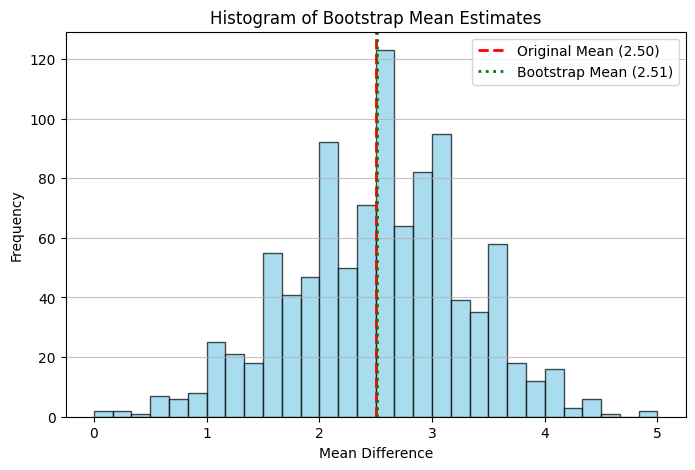

In [ ]:


# Set seed for reproducibility
np.random.seed(42)

# 1. Initialize Paired Observations
before = np.array([18, 16, 21, 24, 20, 19, 23, 17])
after = np.array([15, 18, 15, 20, 18, 17, 19, 16])
n = len(before)

# 2. Calculate paired differences (d_i = Before - After) and sample mean
d = before - after
d_mean = np.mean(d)
print(f"Original Sample Mean (d_bar): {d_mean:.4f}")

# 3. Implement Bootstrap Sampling
B = 1000
bootstrap_means = np.zeros(B)

for b in range(B):
    # Draw n observations with replacement
    bootstrap_sample = np.random.choice(d, size=n, replace=True)
    # Compute bootstrap mean S*b
    bootstrap_means[b] = np.mean(bootstrap_sample)

# 4. Calculate Bootstrap Statistics
# Mean of bootstrap estimates
S_bar_star = np.mean(bootstrap_means)

# Variance of bootstrap estimates (using ddof=1 for 1/(B-1))
S_var_hat = np.var(bootstrap_means, ddof=1)

# Standard deviation of bootstrap estimates
S_std_hat = np.sqrt(S_var_hat)

print(f"Bootstrap Mean (S_bar_star): {S_bar_star:.4f}")
print(f"Bootstrap Variance (Var_hat[S]): {S_var_hat:.4f}")
print(f"Bootstrap Standard Deviation: {S_std_hat:.4f}")

# 5. Plot Histogram
plt.figure(figsize=(8, 5))
plt.hist(bootstrap_means, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(d_mean, color='red', linestyle='dashed', linewidth=2, label=f'Original Mean ({d_mean:.2f})')
plt.axvline(S_bar_star, color='green', linestyle='dotted', linewidth=2, label=f'Bootstrap Mean ({S_bar_star:.2f})')
plt.title('Histogram of Bootstrap Mean Estimates')
plt.xlabel('Mean Difference')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

**Observations and Conclusions:**

* **What the spread of the bootstrap estimates represents:** The spread (variance or standard deviation) of the histogram represents the standard error of the sample mean. It quantifies the uncertainty in our estimate of the true population mean difference. A wider spread indicates greater uncertainty about the true parameter, while a narrower spread indicates higher precision.
* **How bootstrap differs from k-fold CV and LOOCV:**
    * **Sampling Method:** Bootstrap samples data *with replacement*, meaning the same observation can appear multiple times in a single training set. Both $k$-fold CV and LOOCV partition the data *without replacement*, ensuring validation sets and training sets are strictly disjoint and no data point is duplicated.
    * **Primary Objective:** Bootstrap is primarily inferential; it is used to estimate the sampling distribution, variance, and confidence intervals of a population parameter (like a mean). Conversely, $k$-fold CV and LOOCV are predictive evaluation tools used to estimate how well a machine learning model will generalize to unseen independent data.